# GLASS spherical weak-lensing demo

This notebook makes a spherical analogue of the flat-sky diagnostic plot: truth convergence $\kappa$, noisy/masked observed shear $|\gamma_{\rm obs}|$, a spherical Kaiser-Squires-style reconstruction, a smoothed reconstruction, and a simple uncertainty proxy.

GLASS is used to draw the convergence map from an angular power spectrum on a HEALPix sphere, and `glass.from_convergence(..., shear=True)` is used to compute the spin-2 shear field.

In [4]:
from pathlib import Path

import glass
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

OUT = Path("glass_spherical_ks_outputs")
OUT.mkdir(exist_ok=True)

rng = np.random.default_rng(7)
nside = 16
lmax = 3 * nside - 1
npix = hp.nside2npix(nside)
pix = np.arange(npix)
theta, phi = hp.pix2ang(nside, pix)
vec = np.array(hp.pix2vec(nside, pix)).T

ell = np.arange(lmax + 1, dtype=float)
cl_kappa = 0.9 * (ell + 1.0) ** -1.25 * np.exp(-0.006 * ell * (ell + 1.0))
cl_kappa[:2] = 0.0

gls = glass.discretized_cls([cl_kappa], lmax=lmax, nside=nside)
kappa = np.asarray(next(glass.generate([glass.grf.Normal()], gls, nside, rng=rng)))
kappa = hp.remove_dipole(kappa, fitval=False)
kappa = np.ma.filled(kappa, 0.0)
kappa = (kappa - kappa.mean()) / kappa.std()

gamma = glass.from_convergence(kappa, lmax=lmax, shear=True)[0]
gamma = np.asarray(gamma.real) + 1j * np.asarray(gamma.imag)

Could not download pixel weights for nside 16: <urlopen error Unable to open any source! Exceptions were {'https://healpy.github.io/healpy-data/full_weights/healpix_full_weights_nside_0016.fits': <HTTPError 404: 'Not Found'>, 'https://github.com/healpy/healpy-data/releases/download/full_weights/healpix_full_weights_nside_0016.fits': <HTTPError 404: 'Not Found'>}>. Proceeding without pixel weights.


In [5]:
def make_holes(vec, n_holes=22, radius_deg=5.5):
    centers = rng.normal(size=(n_holes, 3))
    centers /= np.linalg.norm(centers, axis=1, keepdims=True)
    cos_radius = np.cos(np.deg2rad(radius_deg))
    mask = np.ones(len(vec), dtype=bool)
    for c in centers:
        mask &= (vec @ c) < cos_radius
    return mask

mask = make_holes(vec)
shape_noise = 0.55
gamma_obs = gamma + shape_noise * (rng.normal(size=npix) + 1j * rng.normal(size=npix))
gamma_obs_masked = gamma_obs.copy()
gamma_obs_masked[~mask] = 0.0

def spherical_kaiser_squires(gamma_map, mask, lmax):
    alm_e, alm_b = hp.map2alm_spin([gamma_map.real, gamma_map.imag], spin=2, lmax=lmax)
    ell_alm, _ = hp.Alm.getlm(lmax)
    response = np.zeros_like(ell_alm, dtype=float)
    good = ell_alm >= 2
    response[good] = 2.0 / np.sqrt((ell_alm[good] - 1) * (ell_alm[good] + 2))
    kappa_alm = alm_e * response
    kappa_rec = hp.alm2map(kappa_alm, nside, lmax=lmax)
    kappa_rec = np.asarray(kappa_rec)
    kappa_rec -= kappa_rec[mask].mean()
    kappa_rec /= kappa_rec[mask].std() + 1e-6
    return kappa_rec

ks = spherical_kaiser_squires(gamma_obs_masked, mask, lmax)
ks_masked = ks.copy()
ks_masked[~mask] = np.nan

reconstruction = hp.smoothing(ks, fwhm=np.deg2rad(7.0), lmax=lmax)
reconstruction = (reconstruction - reconstruction[mask].mean()) / (reconstruction[mask].std() + 1e-6)

uncertainty = hp.smoothing((~mask).astype(float), fwhm=np.deg2rad(10.0), lmax=lmax)
uncertainty += 0.35 * hp.smoothing(np.abs(gamma_obs_masked - gamma), fwhm=np.deg2rad(5.0), lmax=lmax)
uncertainty = (uncertainty - uncertainty.min()) / (uncertainty.max() - uncertainty.min() + 1e-6)

gamma_abs = np.abs(gamma_obs_masked)
gamma_abs[~mask] = np.nan

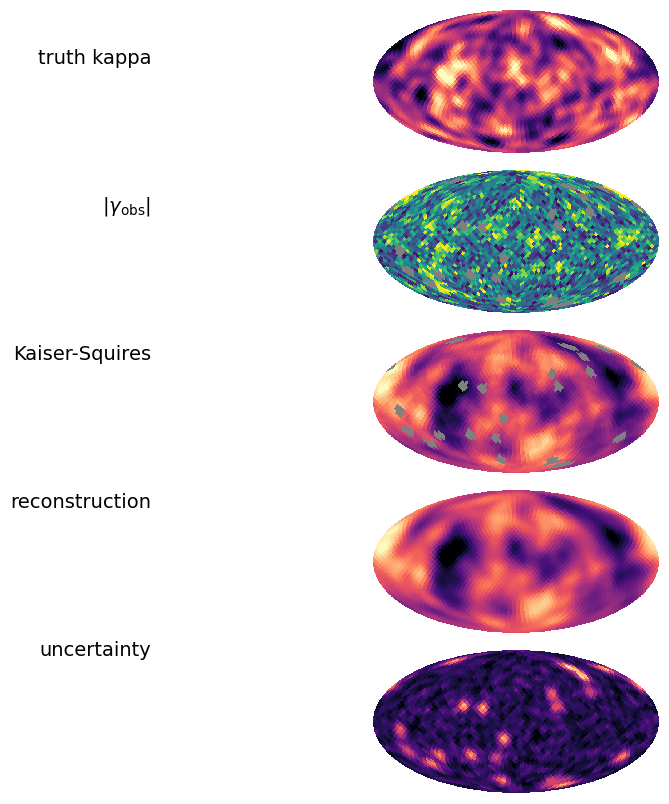

In [10]:
maps = [
    (kappa, "truth kappa", "magma", -2.5, 2.5),
    (gamma_abs, r"$|\gamma_{\rm obs}|$", "viridis", 0.0, np.nanpercentile(gamma_abs, 98)),
    (ks_masked, "Kaiser-Squires", "magma", -2.5, 2.5),
    (reconstruction, "reconstruction", "magma", -2.5, 2.5),
    (uncertainty, "uncertainty", "magma", 0.0, 1.0),
]

fig = plt.figure(figsize=(10, 8), )#facecolor="0.78")
for i, (m, label, cmap, vmin, vmax) in enumerate(maps, start=1):
    hp.mollview(
        m,
        fig=fig.number,
        sub=(5, 1, i),
        cmap=cmap,
        min=vmin,
        max=vmax,
        cbar=False,
        title="",
        # badcolor="0.45",
        # bgcolor="0.8",
    )
    fig.text(0.14, 0.92 - (i - 1) * 0.185, label, ha="right", va="center", fontsize=14,)# color="0.38")

fig.subplots_adjust(left=0.18, right=0.98, top=0.98, bottom=0.03, hspace=0.18)
fig.savefig(OUT / "glass_spherical_ks_rows.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

Notes:

- The first row is a GLASS Gaussian convergence field sampled on a HEALPix sphere.
- The second row is the noisy observed shear amplitude with holes/missing data.
- The third row is a spherical Kaiser-Squires-style inversion using spin-2 spherical harmonics.
- The fourth row is a smoothed reconstruction, included to mimic a denoised posterior mean.
- The fifth row is only a pedagogical uncertainty proxy, high near masked/noisy regions. It is not a calibrated Bayesian uncertainty map.